In [ ]:
----------------------------------------------------------------------------------------------------------
                                              TASK SUBMISSION                                                                                                                                
----------------------------------------------------------------------------------------------------------   
                                                     
  Full Name : chenna Balaji Sri Manikanta           
  Intership Track : Data Analytics                   
  Task Title : Task 2 - Customer Segmentation Analysis   
  Dataset : https://www.kaggle.com/datasets/shriyashjagtap/e-commerce-customer-for-behavior-analysis/data   

----------------------------------------------------------------------------------------------------------

In [1]:
# Importing Python Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset
df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")
df

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,33308,2023-08-10 13:39:06,Clothing,279,2,2187,PayPal,55,1.0,Michelle Flores,55,Male,1
249996,48835,2021-11-23 01:30:42,Home,27,1,3615,Credit Card,42,1.0,Jeremy Rush,42,Female,1
249997,21019,2020-07-02 14:04:48,Home,17,5,2466,Cash,41,0.0,Tina Craig,41,Male,0
249998,49234,2020-12-30 02:02:40,Books,398,2,3668,Crypto,34,0.0,Jennifer Cooper,34,Female,1


In [3]:
# First 5 Rows
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [4]:
# Dataset Shape
print("Number of rows and columns:", df.shape)

Number of rows and columns: (250000, 13)


In [5]:
# Column Data Types
print(df.dtypes)

Customer ID                int64
Purchase Date                str
Product Category             str
Product Price              int64
Quantity                   int64
Total Purchase Amount      int64
Payment Method               str
Customer Age               int64
Returns                  float64
Customer Name                str
Age                        int64
Gender                       str
Churn                      int64
dtype: object


In [6]:
# Missing Values
print(df.isnull().sum())

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64


In [7]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  str    
 2   Product Category       250000 non-null  str    
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  str    
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  str    
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  str    
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 37.1 MB


In [8]:
# Check Returns Values
print(df["Returns"].value_counts(dropna=False))

Returns
0.0    101635
1.0    100769
NaN     47596
Name: count, dtype: int64


In [9]:
# Replace Missing Returns with 0
df["Returns"] = df["Returns"].fillna(0)

In [10]:
# Check null Exists
print(df.isnull().sum())

Customer ID              0
Purchase Date            0
Product Category         0
Product Price            0
Quantity                 0
Total Purchase Amount    0
Payment Method           0
Customer Age             0
Returns                  0
Customer Name            0
Age                      0
Gender                   0
Churn                    0
dtype: int64


In [11]:
# Customer-Level Descriptive Statistics
customer_stats = df.groupby("Customer ID").agg(
    Average_Purchase_Value=("Total Purchase Amount", "mean"),
    Purchase_Frequency=("Customer ID", "count"),
    Customer_Lifetime_Value=("Total Purchase Amount", "sum")
)

customer_stats.head()

,Average_Purchase_Value,Purchase_Frequency,Customer_Lifetime_Value
Customer ID,,,
1,3491.000000,1,3491
2,2662.666667,3,7988
3,2823.375000,8,22587
4,2178.750000,4,8715
5,1565.500000,8,12524


In [12]:
# Descriptive Statistics
customer_stats.describe()

,Average_Purchase_Value,Purchase_Frequency,Customer_Lifetime_Value
count,49673.000000,49673.000000,49673.000000
mean,2724.642085,5.032915,13716.559962
std,737.013884,2.206427,6840.208557
min,110.000000,1.000000,110.000000
25%,2255.714286,3.000000,8719.000000
50%,2728.600000,5.000000,13026.000000
75%,3191.200000,6.000000,17966.000000
max,5288.000000,17.000000,55339.000000


The analysis shows how much customers spend, how often they purchase, and their total spending.

In [13]:
# Convert Purchase Date
df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])

In [15]:
# Create RFM Features
reference_date = df["Purchase Date"].max()

rfm = df.groupby("Customer ID").agg(
    Recency=("Purchase Date", lambda x: (reference_date - x.max()).days),
    Frequency=("Customer ID", "count"),
    Monetary=("Total Purchase Amount", "sum")
)

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,57,1,3491
2,298,3,7988
3,88,8,22587
4,126,4,8715
5,170,8,12524


In [16]:
# Standardize RFM Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[["Recency", "Frequency", "Monetary"]]
)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm.index
)

display(rfm_scaled.head())

,Recency,Frequency,Monetary
Customer ID,,,
1,-0.826858,-1.827822,-1.494934
2,0.152731,-0.921370,-0.837492
3,-0.700853,1.344760,1.296821
4,-0.546395,-0.468144,-0.731207
5,-0.367549,1.344760,-0.174347


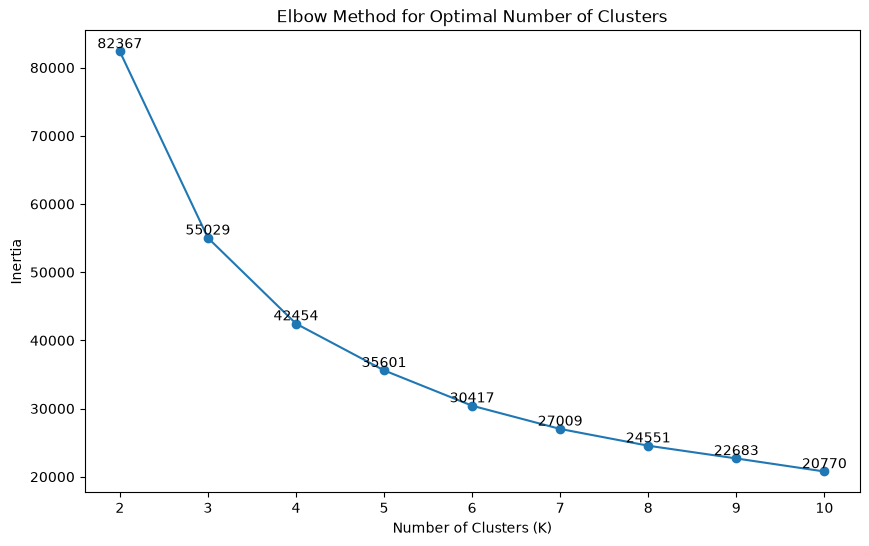

In [18]:
# Elbow Method
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))

plt.plot(range(2, 11), inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))

# Display values on the line
for x, y in zip(range(2, 11), inertia):
    plt.text(x, y, f"{y:.0f}", ha="center", va="bottom")
    
plt.show()

Observation : The inertia decreases as the number of clusters increases. The elbow point shows the suitable number of clusters for customer segmentation.

In [20]:
# Apply K-Means

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

display(rfm.head())

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
1,57,1,3491,2
2,298,3,7988,2
3,88,8,22587,0
4,126,4,8715,2
5,170,8,12524,1


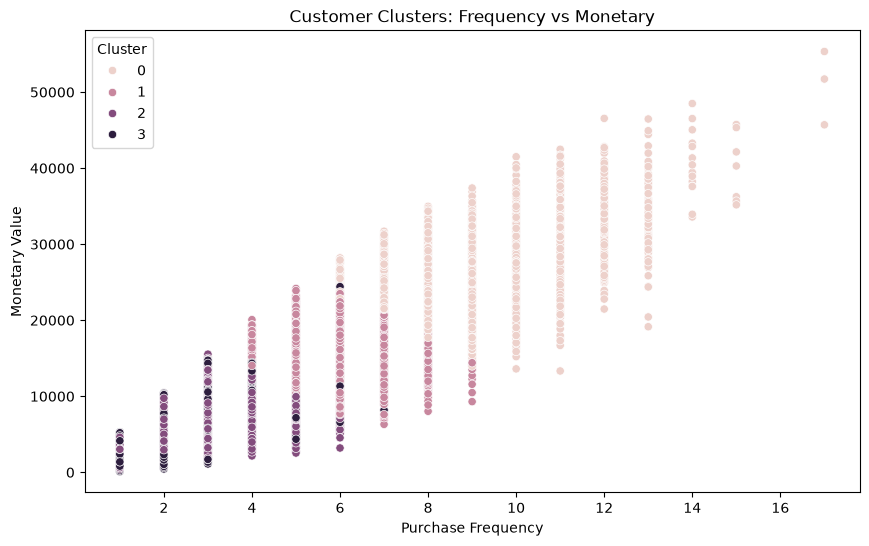

In [21]:
# Scatter Plot: Frequency vs Monetary
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster"
)

plt.title("Customer Clusters: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")

plt.show()

Observation : The graph shows that customers who purchase more frequently generally spend more. This helps identify frequent and high-value customers.

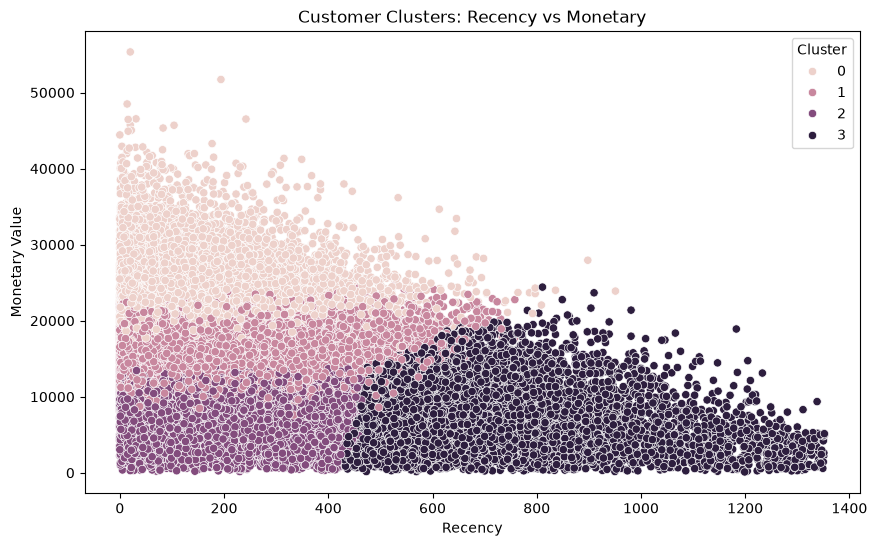

In [23]:
# Scatter Plot: Recency vs Monetary
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster"
)

plt.title("Customer Clusters: Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary Value")

plt.show()

Obseravtion :  The graph shows four customer groups with different recency and spending patterns. Some customers have spent more recently, while others have not purchased for a longer time.

In [25]:
# Profile Each Cluster
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

display(cluster_profile)

,Recency,Frequency,Monetary
Cluster,,,
0,135.843843,8.440577,24494.153654
1,182.652246,5.715804,15614.061368
2,193.014351,3.332216,8292.908731
3,718.847954,2.939600,7825.245392


Cluster Profile

Cluster 0 : These are the best customers. They buy often and spend more.

Cluster 1 : These are regular customers who buy and spend a moderate amount.

Cluster 2 : These customers buy less and spend less.

Cluster 3 : These customers have not bought anything for a long time. They may need offers to come back.

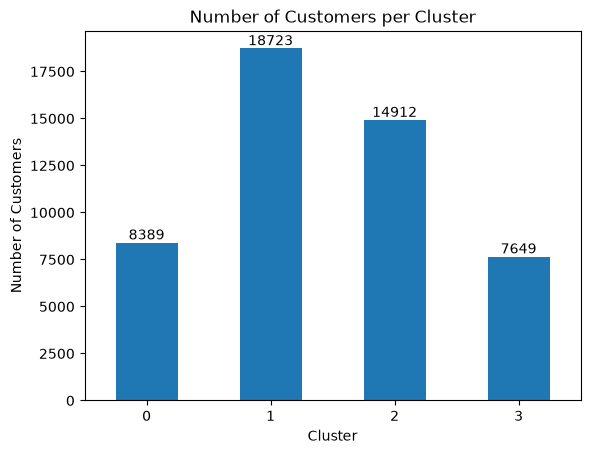

In [27]:
# Number of Customers in Each Cluster
cluster_size = rfm["Cluster"].value_counts().sort_index()

ax = cluster_size.plot(kind="bar")

plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

for x, y in enumerate(cluster_size):
    ax.text(x, y, str(y), ha="center", va="bottom")

plt.show()

Observation : One group has the largest number of customers, while another group has the fewest. This shows that customer behavior varies across different segments.

                                                    Insights

Cluster 0 : These customers are valuable, so we should give them loyalty rewards and special offers.

Cluster 1 : We can give them discounts and offers to encourage them to shop more.

Cluster 2 : We can use promotions and discounts to increase their purchases.

Cluster 3 : These customers may have stopped buying, so we can send special offers to bring them back.